In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import ants

import matplotlib.pyplot as plt

# Optional but recommended
#!pip install nilearn seaborn
from nilearn import image, masking, plotting, datasets
import seaborn as sns

sns.set_context("talk")
plt.rcParams["figure.dpi"] = 120


/csc/epitkane/home/atagmazi/.conda/envs/atagmazi_gpu8/lib/python3.7/site-packages/nilearn/__init__.py:67: FutureWarning:

Python 3.7 support is deprecated and will be removed in release 0.12 of Nilearn. Consider switching to Python 3.9 or 3.10.



In [2]:

mni_t1 = ants.image_read('/csc/epitkane/home/atagmazi/tpl-MNI152NLin6Asym_res-01_T1w.nii.gz')

#mask_img = nib.load('/csc/epitkane/home/atagmazi/Hammer_brain_atlas/Hammers_mith_atlas_n30r83_SPM5.nii.gz')
#mask_img =  ants.resample_image_to_target(bm, mni_t1, interp_type='nearestNeighbor').astype('uint32').numpy()




In [3]:
# Our metafile
date = '26_05_25'
#path = '/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/VAE_model/' + date
path = '/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/bimodal_VAE/' + date
meta2=  pd.read_csv(path + '/metafile_shuffled_'+ date+'.csv',header=[0], index_col=[0], low_memory = False)

meta2.loc[meta2['Research.Group']=='LMCI','Research.Group'] = 'MCI'
meta2.loc[meta2['Research.Group']=='EMCI','Research.Group'] = 'MCI'
meta2['Subject.ID'] = meta2['MRI_subID'] #something happened with Subject.ID columns, there are 0 in some rows

## Load latent features

Your `run_model.py` writes a CSV where:
- **columns** are `scan_id`
- **rows** are feature indices `0..(n_features-1)`

We’ll load it into a matrix shaped `(n_scans, n_features)` for analysis.


In [6]:
df_train = pd.read_csv(path + '/latent_features_train2_'+ date+'.csv', index_col = 0)
df_validation = pd.read_csv(path + '/latent_features_validation2_'+ date+'.csv', index_col = 0)
df_test = pd.read_csv(path + '/latent_features_test2_'+ date+'.csv', index_col = 0)

df_all = pd.concat([df_train,df_validation,df_test], axis = 1)

In [7]:
ids = []
id_colname = []
for col in df_all.columns:
    #ids.append(col.split('_')[0]) # 1modality 
    ids.append(col.split('/')[6].split('_')[0])
    id_colname.append(col.split('/')[6])
ids_unique = list(dict.fromkeys(ids)) 
df_all.columns = id_colname

In [8]:
# concatenate features from slices to scan level
pet_combined_df = pd.DataFrame()
for i in ids_unique:
    #Find columns that start with the current ID
    columns = [col for col in df_all.columns if col.startswith(i)]
    
    # Concatenate the matching columns vertically
    concat = pd.concat([df_all[col] for col in columns], ignore_index=True)
    
    # Assign the concatenated result to a new column in the combined DataFrame
    pet_combined_df[i] = concat
    
print('combined pet features')


combined pet features


In [9]:
pet_combined_df

,I1323673,I393755,I413047,I1411194,I1411241,I600580,I238678,I1321766,I1322960,I199400,...,I344099,I397124,I1410419,I389844,I1411212,I468830,I209032,I391868,I445087,I202039
0,0.003467,0.003467,0.003467,0.003467,0.003467,0.003467,0.003467,0.003467,0.003467,0.003467,...,0.003467,0.003467,0.003467,0.003467,0.003467,0.003467,0.003467,0.003467,0.003467,0.003467
1,-0.000853,-0.000853,-0.000853,-0.000853,-0.000853,-0.000853,-0.000853,-0.000853,-0.000853,-0.000853,...,-0.000853,-0.000853,-0.000853,-0.000853,-0.000853,-0.000853,-0.000853,-0.000853,-0.000853,-0.000853
2,-0.008092,-0.008092,-0.008092,-0.008092,-0.008092,-0.008092,-0.008092,-0.008092,-0.008092,-0.008092,...,-0.008092,-0.008092,-0.008092,-0.008092,-0.008092,-0.008092,-0.008092,-0.008092,-0.008092,-0.008092
3,-0.006697,-0.006697,-0.006697,-0.006697,-0.006697,-0.006697,-0.006697,-0.006697,-0.006697,-0.006697,...,-0.006697,-0.006697,-0.006697,-0.006697,-0.006697,-0.006697,-0.006697,-0.006697,-0.006697,-0.006697
4,-0.000326,-0.000326,-0.000326,-0.000326,-0.000326,-0.000326,-0.000326,-0.000326,-0.000326,-0.000326,...,-0.000326,-0.000326,-0.000326,-0.000326,-0.000326,-0.000326,-0.000326,-0.000326,-0.000326,-0.000326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11643,0.000851,0.000851,0.000851,0.000851,0.000851,0.000851,0.000851,0.000851,0.000851,0.000851,...,0.000851,0.000851,0.000851,0.000851,0.000851,0.000851,0.000851,0.000851,0.000851,0.000851
11644,0.001998,0.001998,0.001998,0.001998,0.001998,0.001998,0.001998,0.001998,0.001998,0.001998,...,0.001998,0.001998,0.001998,0.001998,0.001998,0.001998,0.001998,0.001998,0.001998,0.001998
11645,0.002428,0.002428,0.002428,0.002428,0.002428,0.002428,0.002428,0.002428,0.002428,0.002428,...,0.002428,0.002428,0.002428,0.002428,0.002428,0.002428,0.002428,0.002428,0.002428,0.002428
11646,-0.000050,-0.000050,-0.000050,-0.000050,-0.000050,-0.000050,-0.000050,-0.000050,-0.000050,-0.000050,...,-0.000050,-0.000050,-0.000050,-0.000050,-0.000050,-0.000050,-0.000050,-0.000050,-0.000050,-0.000050


In [10]:
latent_df = pet_combined_df
# ---- Feature selection results (paste from your analysis notebook) ----
SELECTED_FEATURES = [2905, 3014, 3033, 3161, 3225, 3270, 3277, 7022, 7086, 7693]
#[2905, 3014, 3161, 3225, 3277, 6894, 7022, 7086, 7150]

# ---- VAE settings (must match training/inference) ----
LATENT_SIZE = 64   # mu length per slice
# latent_df: rows = feature_index, cols = scan_id
latent_df.index = latent_df.index.astype(int)

print("latent_df shape (n_features, n_scans):", latent_df.shape)
#print("example scan_ids:", latent_df.columns[:5].tolist())

# X: (n_scans, n_features)
X_lat = latent_df.T
print("X_lat shape (n_scans, n_features):", X_lat.shape)

missing = [f for f in SELECTED_FEATURES if f not in X_lat.columns]
if missing:
    raise ValueError(f"Selected feature(s) not found in latent CSV columns: {missing}")


latent_df shape (n_features, n_scans): (11648, 3110)
X_lat shape (n_scans, n_features): (3110, 11648)


## Map feature index → (slice_index, latent_dim)

This is useful for interpretation/debugging (e.g., “feature 2905 is slice 45, latent dim 25” if `LATENT_SIZE=64`).


In [11]:
feat_map = pd.DataFrame({
    "feature_index": SELECTED_FEATURES,
})
feat_map["slice_index"] = feat_map["feature_index"] // LATENT_SIZE
feat_map["latent_dim"] = feat_map["feature_index"] % LATENT_SIZE
feat_map

,feature_index,slice_index,latent_dim
0,2905,45,25
1,3014,47,6
2,3033,47,25
3,3161,49,25
4,3225,50,25
5,3270,51,6
6,3277,51,13
7,7022,109,46
8,7086,110,46
9,7693,120,13


In [13]:
# ordering so same latent dim will be next to each other for easier comparison 
SELECTED_FEATURES = [2905,3033, 3161, 3225, 3014,  3270, 3277, 7693, 7022, 7086]

## Load PET volumes for the same scans

You can provide a `scan_id → nifti_path` mapping CSV, or point to a directory and we’ll auto-match filenames.

Important:
- All images should be in the **same space** (same shape + affine) for voxelwise correlation.
- Use **reconstructed PET** or **original PET** consistently.


In [12]:
meta2.columns

Index(['Project', 'Phase', 'Sex', 'Weight', 'Research.Group', 'VISCODE',
       'Study.Date', 'Age', 'Modality', 'Description', 'Imaging.Protocol',
       'Image.Data.ID', 'modality_subtype', 'PATH', 'MRI_subID',
       'MRI_Modality', 'MRI_Research.Group', 'MRI_Age', 'MRI_VISCODE',
       'MRI_studydate', 'MRI_Description', 'MRI_Imaging.protocol', 'MRI_Type',
       'MRI_ID', 'MRI_PATH', 'PET_PATH_normalised', 'MRI_PATH_registered',
       'pet_min', 'pet_max', 'pet_90q', 'pet_95q', 'pet_99q', 'pet_999q',
       'mri_min', 'mri_max', 'mri_90q', 'mri_95q', 'mri_99q', 'mri_999q',
       'Subject.ID'],
      dtype='object')

In [ ]:
folder = path+'/feature_brain_maps/'
pet_paths = [os.path.join(folder, f) for f in os.listdir(folder)
         if os.path.isfile(os.path.join(folder, f))]

print(pet_paths)

In [16]:
SELECTED_FEATURES = ['2905','3033','3161','3225','3014','3270','3277','7693','7022','7086']

In [17]:
corr_maps = {} 
for number,feature in enumerate(SELECTED_FEATURES):
    corr_maps[feature] = nib.load(pet_paths[number])
    #[nib.load(p) for p in pet_paths]

In [18]:
corr_maps

{'2905': <nibabel.nifti1.Nifti1Image at 0x7f87a35b7710>,
 '3033': <nibabel.nifti1.Nifti1Image at 0x7f87a35c6550>,
 '3161': <nibabel.nifti1.Nifti1Image at 0x7f87a35c63d0>,
 '3225': <nibabel.nifti1.Nifti1Image at 0x7f87a35c6590>,
 '3014': <nibabel.nifti1.Nifti1Image at 0x7f87a35c64d0>,
 '3270': <nibabel.nifti1.Nifti1Image at 0x7f87a35c6910>,
 '3277': <nibabel.nifti1.Nifti1Image at 0x7f87a35c68d0>,
 '7693': <nibabel.nifti1.Nifti1Image at 0x7f87a35c6bd0>,
 '7022': <nibabel.nifti1.Nifti1Image at 0x7f87a35c6e90>,
 '7086': <nibabel.nifti1.Nifti1Image at 0x7f87a35c6ed0>}

In [110]:
'''# ordering so same latent dim will be next to each other for easier comparison 
SELECTED_FEATURES_reorder = [2905,3033, 3161, 3225, 3014,  3270, 3277, 7693, 7022, 7086]

order = ['2905','3033','3161','3225','3014','3270','3277','7693','7022','7086']
corr_maps = {k: corr_maps[k] for k in order}'''

In [65]:
img0 = corr_maps['2905'].get_fdata()

In [70]:
affine = corr_maps['2905'].affine

# Voxel index → MNI mm
voxel_idx = 45
mni_z = affine[2, 2] * voxel_idx + affine[2, 3]
print(f"Voxel 45 → z = {mni_z:.1f} mm")

Voxel 45 → z = -27.0 mm


In [67]:
img0.shape

(182, 218, 182)

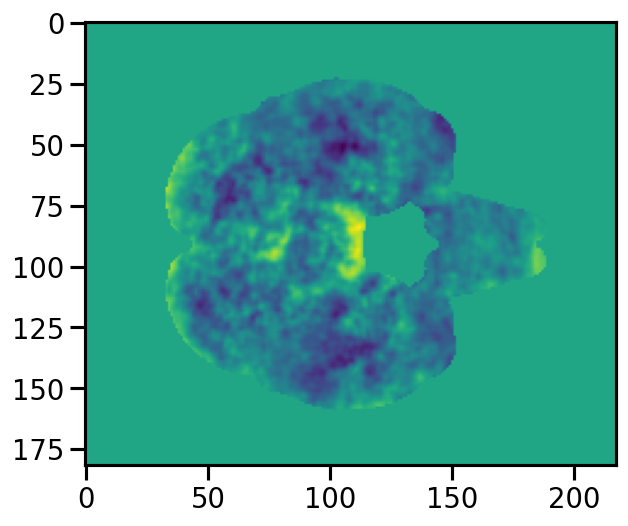

In [68]:
plt.imshow(img0[:,:,45])

In [113]:
np.max(img0)

0.0739559456706047

In [118]:
corr_vectors['2905']

array([-0.01238667, -0.0155023 , -0.01553674, ...,  0.01454818,
        0.01044388,  0.00878419], dtype=float32)

(array([1.05200e+03, 2.29950e+04, 1.69954e+05, 4.96420e+05, 6.00592e+05,
        3.95876e+05, 1.51012e+05, 3.97150e+04, 5.15400e+03, 2.19000e+02]),
 array([-0.07914758, -0.06383723, -0.04852688, -0.03321652, -0.01790617,
        -0.00259582,  0.01271453,  0.02802489,  0.04333524,  0.05864559,
         0.07395595], dtype=float32),
 <BarContainer object of 10 artists>)

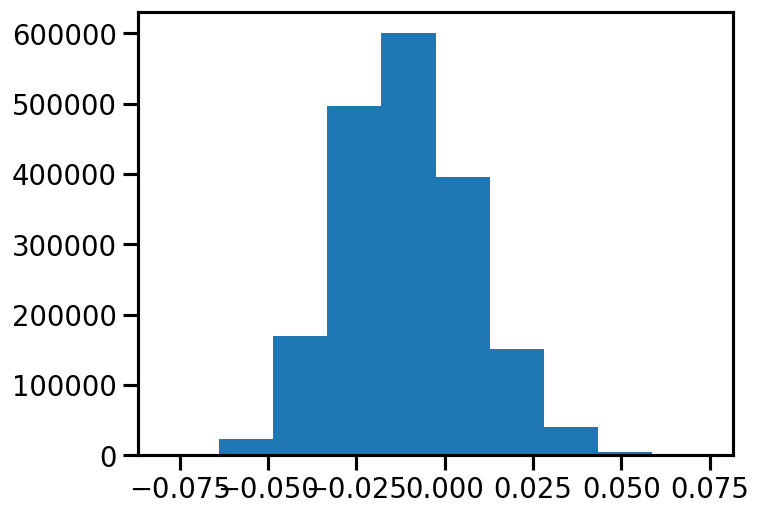

In [119]:
plt.hist(corr_vectors['2905'])

In [72]:
plotting.plot_stat_map(
        corr_maps[0],
        bg_img=BACKGROUND_IMG,
        threshold=0.10,
        display_mode="ortho",
        colorbar=False,  # important: avoid clutter
        title=f"Feature {f0}",
        axes=axes[i],
        figure=fig
    )

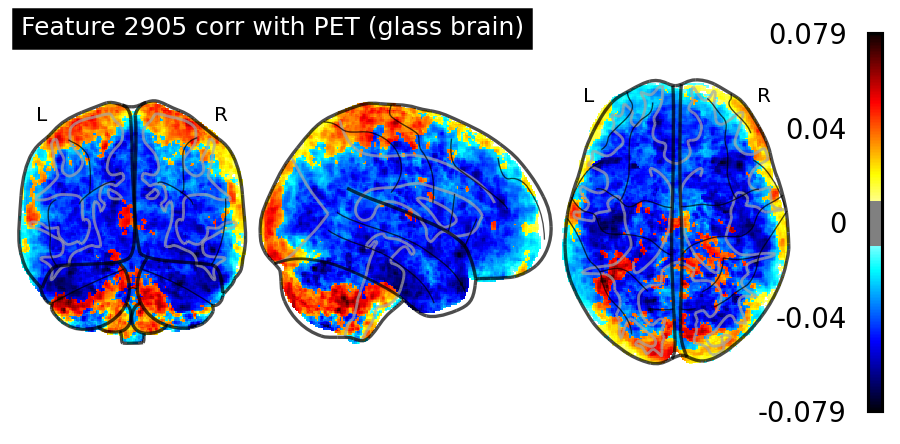

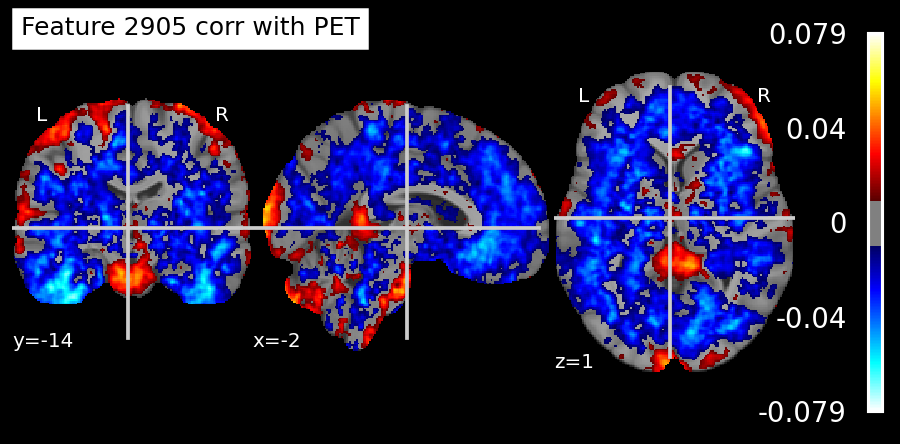

In [23]:
BACKGROUND_IMG = datasets.load_mni152_template()
f0 = SELECTED_FEATURES[0]
img0 = corr_maps[f0]

display = plotting.plot_glass_brain(
    img0,
    threshold=0.01,
    colorbar=True,
    plot_abs=False,
    title=f"Feature {f0} corr with PET (glass brain)",
)

display = plotting.plot_stat_map(
    img0,
    bg_img=BACKGROUND_IMG,
    threshold=0.01,
    display_mode="ortho",
    colorbar=True,
    title=f"Feature {f0} corr with PET",
)

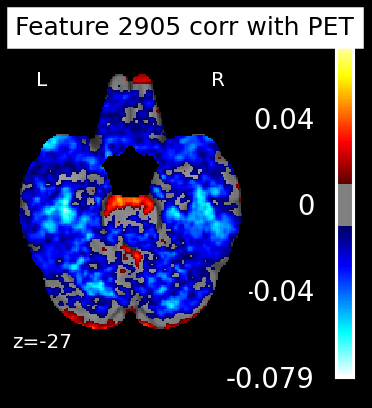

In [71]:
BACKGROUND_IMG = datasets.load_mni152_template()
f0 = SELECTED_FEATURES[0]
img0 = corr_maps[f0]


display = plotting.plot_stat_map(
    img0,
    bg_img=BACKGROUND_IMG,
    threshold=0.01,
    display_mode="z",
    cut_coords=[-27],
    colorbar=True,
    title=f"Feature {f0} corr with PET",
)

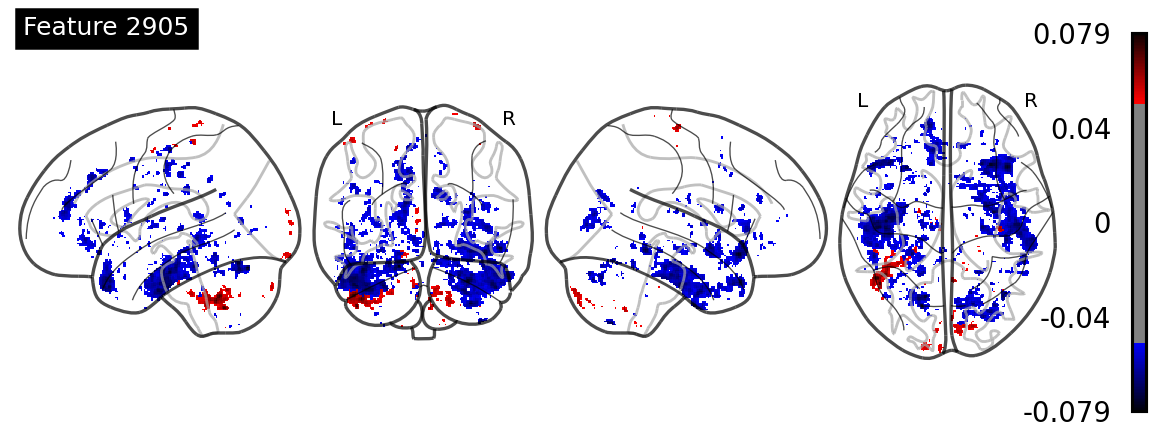

In [78]:
BACKGROUND_IMG = datasets.load_mni152_template()
f0 = SELECTED_FEATURES[0]
img0 = corr_maps[f0]

plotting.plot_glass_brain(
    img0,
    threshold=0.05,
    colorbar=True,
    plot_abs=False,        # show both positive and negative
    display_mode="lyrz",   # left, y, right, z projections
    title=f"Feature {f0}"
)

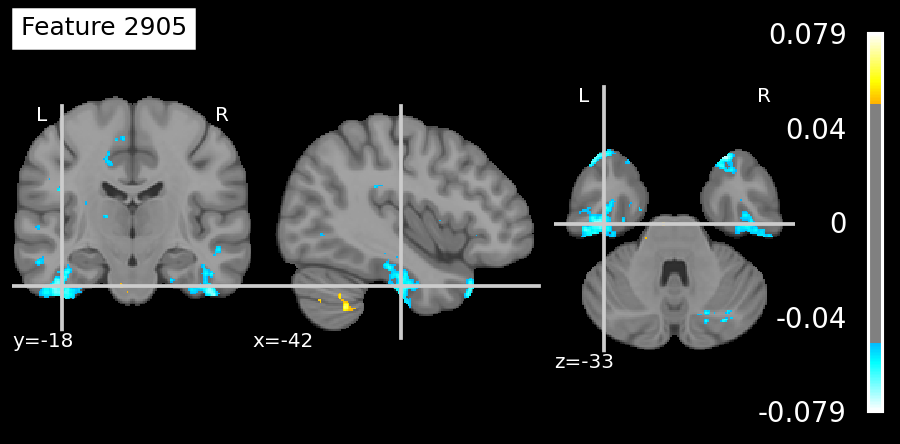

In [74]:
from nilearn.reporting import get_clusters_table
BACKGROUND_IMG = datasets.load_mni152_template()
f0 = SELECTED_FEATURES[0]
img0 = corr_maps[f0]
# Find peak coordinate automatically
peak_coords = plotting.find_xyz_cut_coords(img0, activation_threshold=0.05)

plotting.plot_stat_map(
    img0,
    bg_img=BACKGROUND_IMG,
    display_mode="ortho",
    cut_coords=peak_coords,   # centers on the strongest correlation
    threshold=0.05,
    colorbar=True,
    title=f"Feature {f0}"
)

In [76]:
from nilearn.reporting import get_clusters_table

table = get_clusters_table(img0, stat_threshold=0.05)
print(table)
# Returns: region name, peak MNI coords, peak value, cluster size

   Cluster ID     X     Y     Z  Peak Stat Cluster Size (mm3)
0           1 -46.0 -54.0 -43.0   0.073956                839
1          1a -44.0 -57.0 -51.0   0.072831                   
2          1b -39.0 -48.0 -46.0   0.064995                   
3          1c -32.0 -44.0 -48.0   0.060088                   
4           2   5.0 -56.0 -52.0   0.064454                 22
..        ...   ...   ...   ...        ...                ...
57         55  -3.0 -18.0 -37.0   0.050394                  1
58         56 -33.0 -43.0 -52.0   0.050392                  1
59         57   6.0 -76.0 -51.0   0.050380                  1
60         58 -11.0 -96.0 -17.0   0.050204                  1
61         59  38.0 -62.0 -51.0   0.050098                  1

[62 rows x 6 columns]


In [51]:
all_data = [corr_maps[f0].get_fdata() for f0 in SELECTED_FEATURES]
vmin = np.min([np.min(d) for d in all_data])
vmax = np.max([np.max(d) for d in all_data])

In [53]:
vmax

0.08793111890554428

ValueError: Unable to create a colorbar axes as not all parents share the same figure.

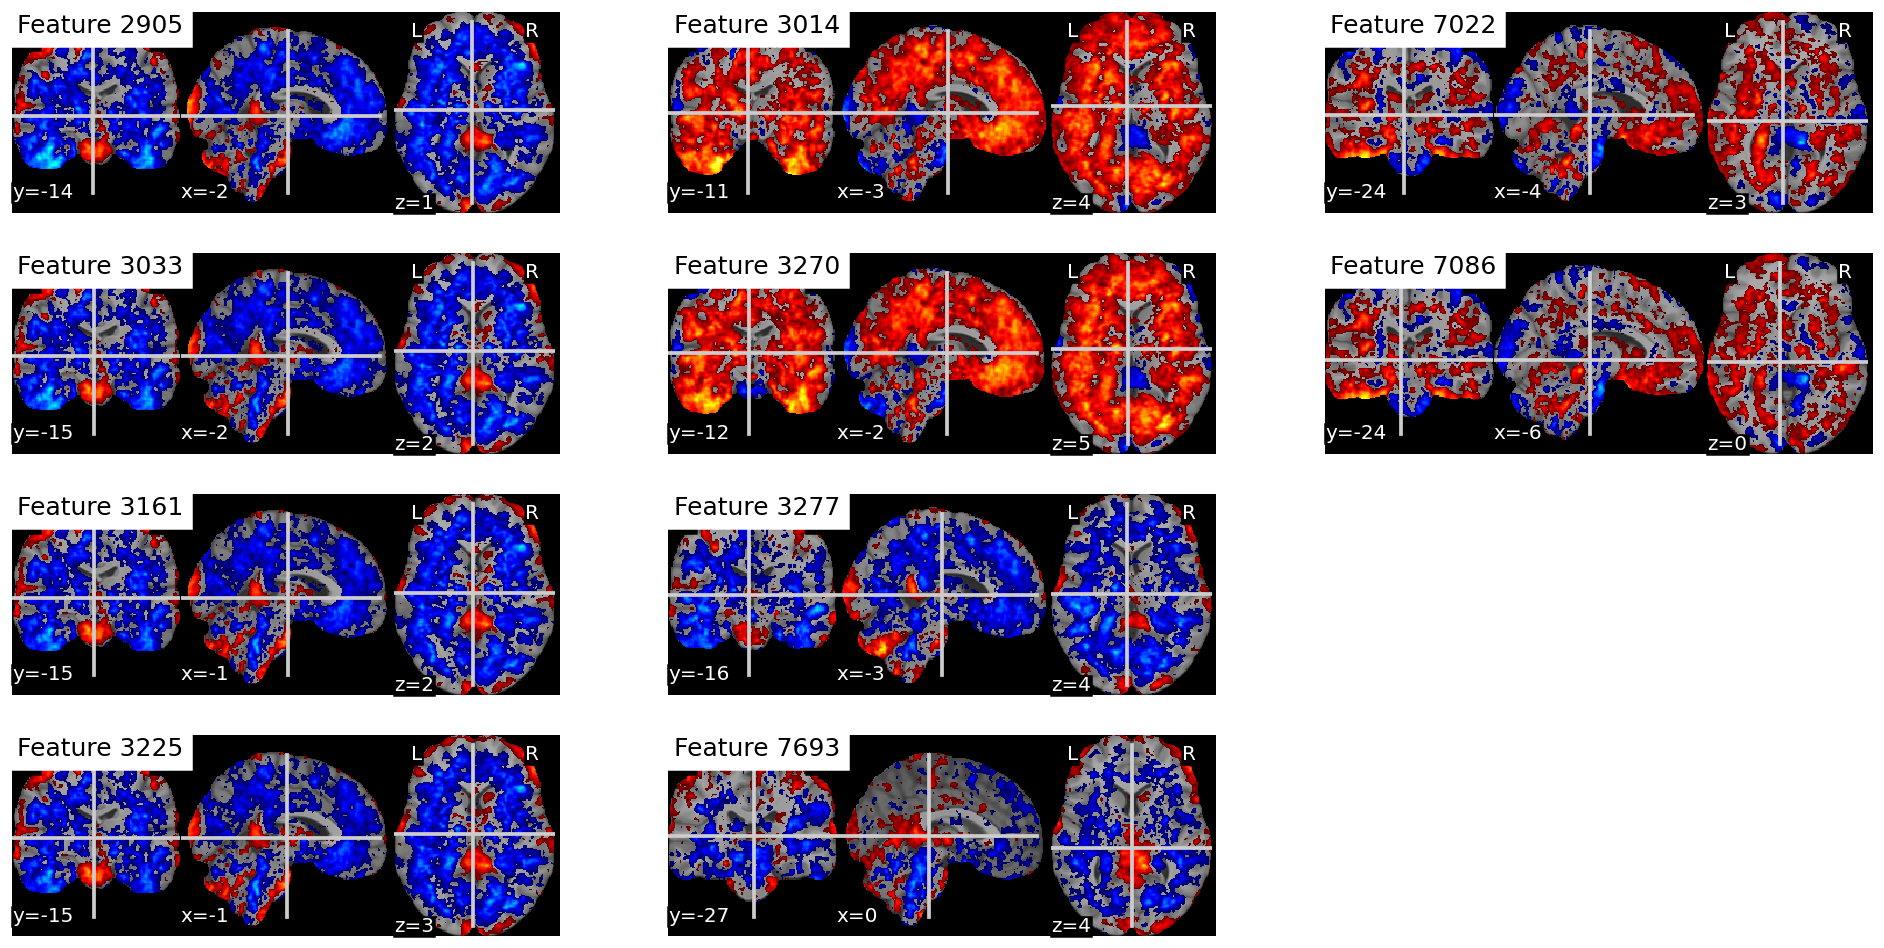

In [59]:
import matplotlib.pyplot as plt
from nilearn import plotting, datasets
import matplotlib as mpl

BACKGROUND_IMG = datasets.load_mni152_template()

fig, axes = plt.subplots(4, 3, figsize=(20, 10))  # 2 rows × 5 columns
axes = axes.flatten(order='F')  # flatten to 1D for easy looping

for i in range(10):
    f0 = SELECTED_FEATURES[i]
    img0 = corr_maps[f0]

    plotting.plot_stat_map(
        img0,
        bg_img=BACKGROUND_IMG,
        threshold=0.01,
        display_mode="ortho",
        colorbar=False,  # important: avoid clutter
        symmetric_cbar=False,
        title=f"Feature {f0}",
        axes=axes[i],
        figure=fig,
        #vmin=vmin,
        vmax=vmax
    )
axes[-1].remove()
axes[-2].remove()

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap='cold_hot', norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.02, pad=0.02)
cbar.set_label("Correlation value")

#plt.tight_layout()
plt.savefig(path + f'/features_brain_plot_{date}.png', bbox_inches='tight')
plt.savefig(path + f'/features_brain_plot_{date}.svg', format='svg', bbox_inches='tight')


plt.show()

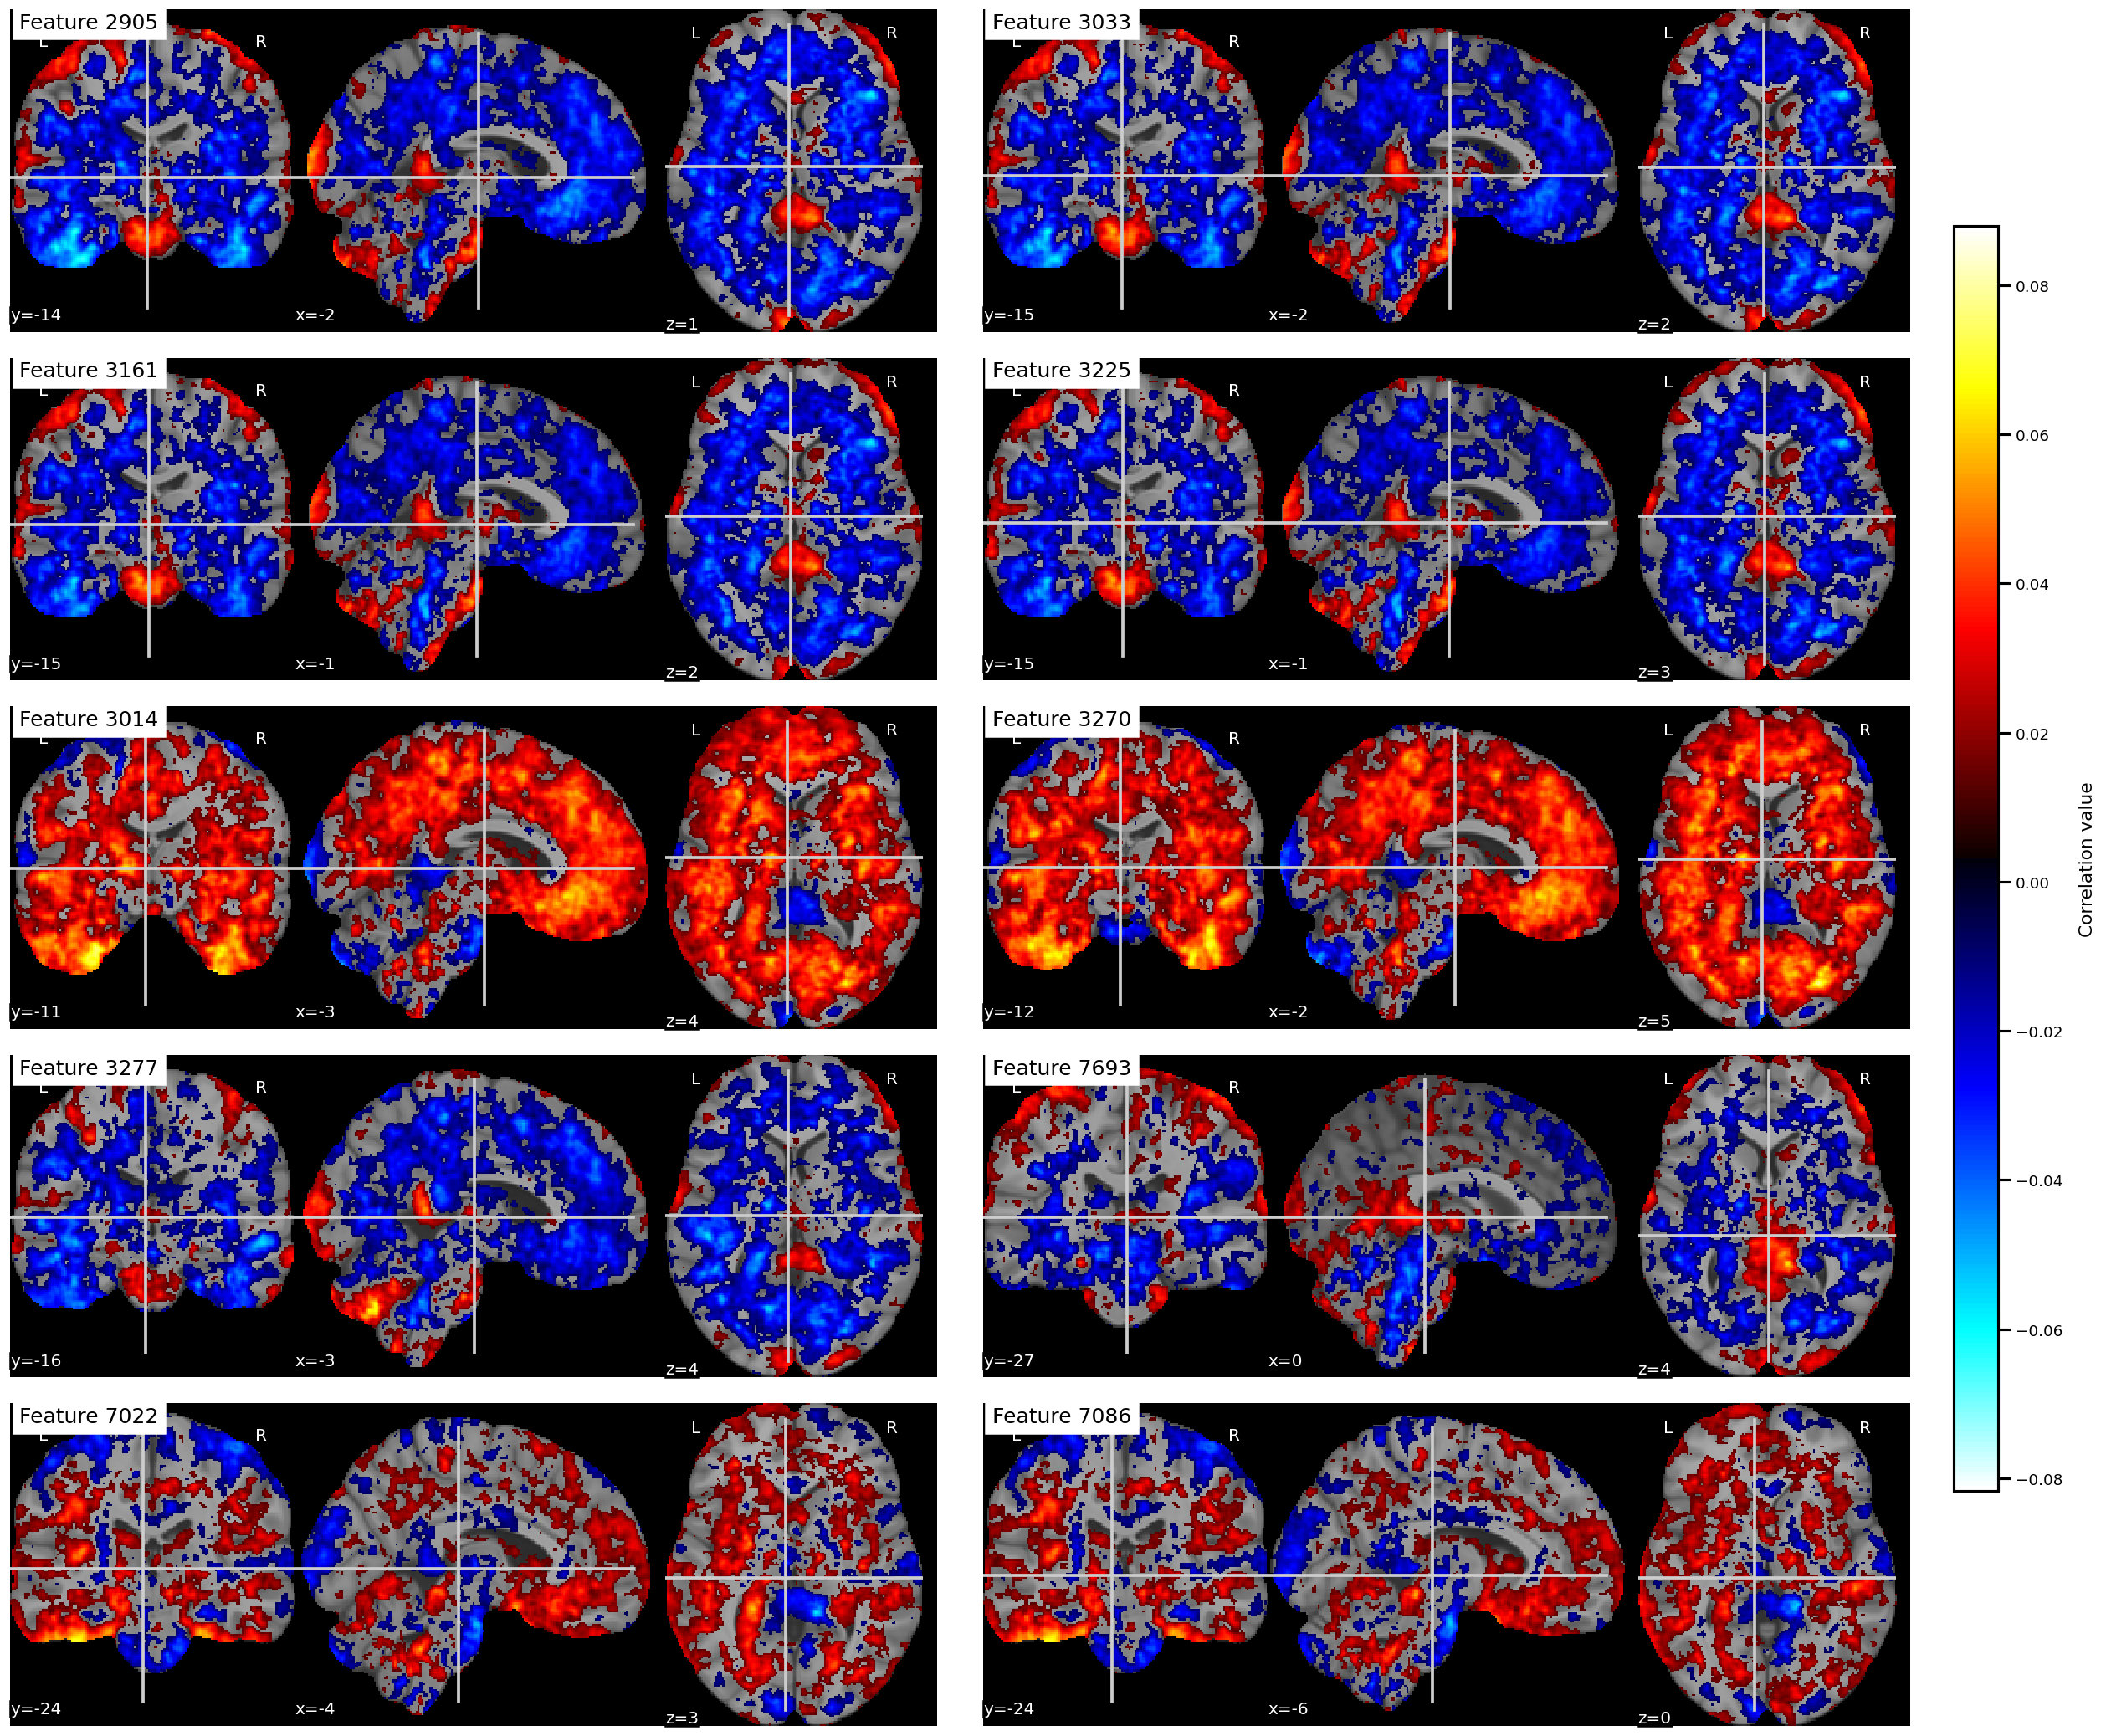

In [63]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from nilearn import plotting, datasets

BACKGROUND_IMG = datasets.load_mni152_template()

# ----------------------------
# 1. Compute global vmin/vmax
# ----------------------------
all_data = [corr_maps[f0].get_fdata() for f0 in SELECTED_FEATURES[:10]]
vmin = np.nanmin([np.nanmin(d) for d in all_data])
vmax = np.nanmax([np.nanmax(d) for d in all_data])

# ----------------------------
# 2. Create subplot grid (5 rows x 2 cols)
#    Reserve right margin for shared colorbar
# ----------------------------
fig = plt.figure(figsize=(22, 18))

# Leave ~5% on the right for the colorbar
gs = fig.add_gridspec(
    5, 2,
    left=0.02, right=0.88,
    top=0.97, bottom=0.02,
    hspace=0.08, wspace=0.05
)

axes = [fig.add_subplot(gs[r, c]) for r in range(5) for c in range(2)]

# ----------------------------
# 3. Plot maps — no individual colorbars
# ----------------------------
for i in range(10):
    f0 = SELECTED_FEATURES[i]
    img0 = corr_maps[f0]
    plotting.plot_stat_map(
        img0,
        bg_img=BACKGROUND_IMG,
        threshold=0.01,
        display_mode="ortho",
        colorbar=False,          # ← disabled per-plot colorbar
        title=f"Feature {f0}",
        axes=axes[i],
        figure=fig,
        vmax=vmax
    )

# ----------------------------
# 4. Single shared colorbar on the right
# ----------------------------
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.70])  # [left, bottom, width, height]

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap='cold_hot')
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Correlation value", fontsize=13, labelpad=12)
cbar.ax.tick_params(labelsize=11)

# ----------------------------
# 5. Save + show
# ----------------------------
plt.savefig(path + f'/features_brain_plot_{date}.png', dpi=150, bbox_inches='tight')
plt.savefig(path + f'/features_brain_plot_{date}.svg', format='svg', bbox_inches='tight')
plt.show()

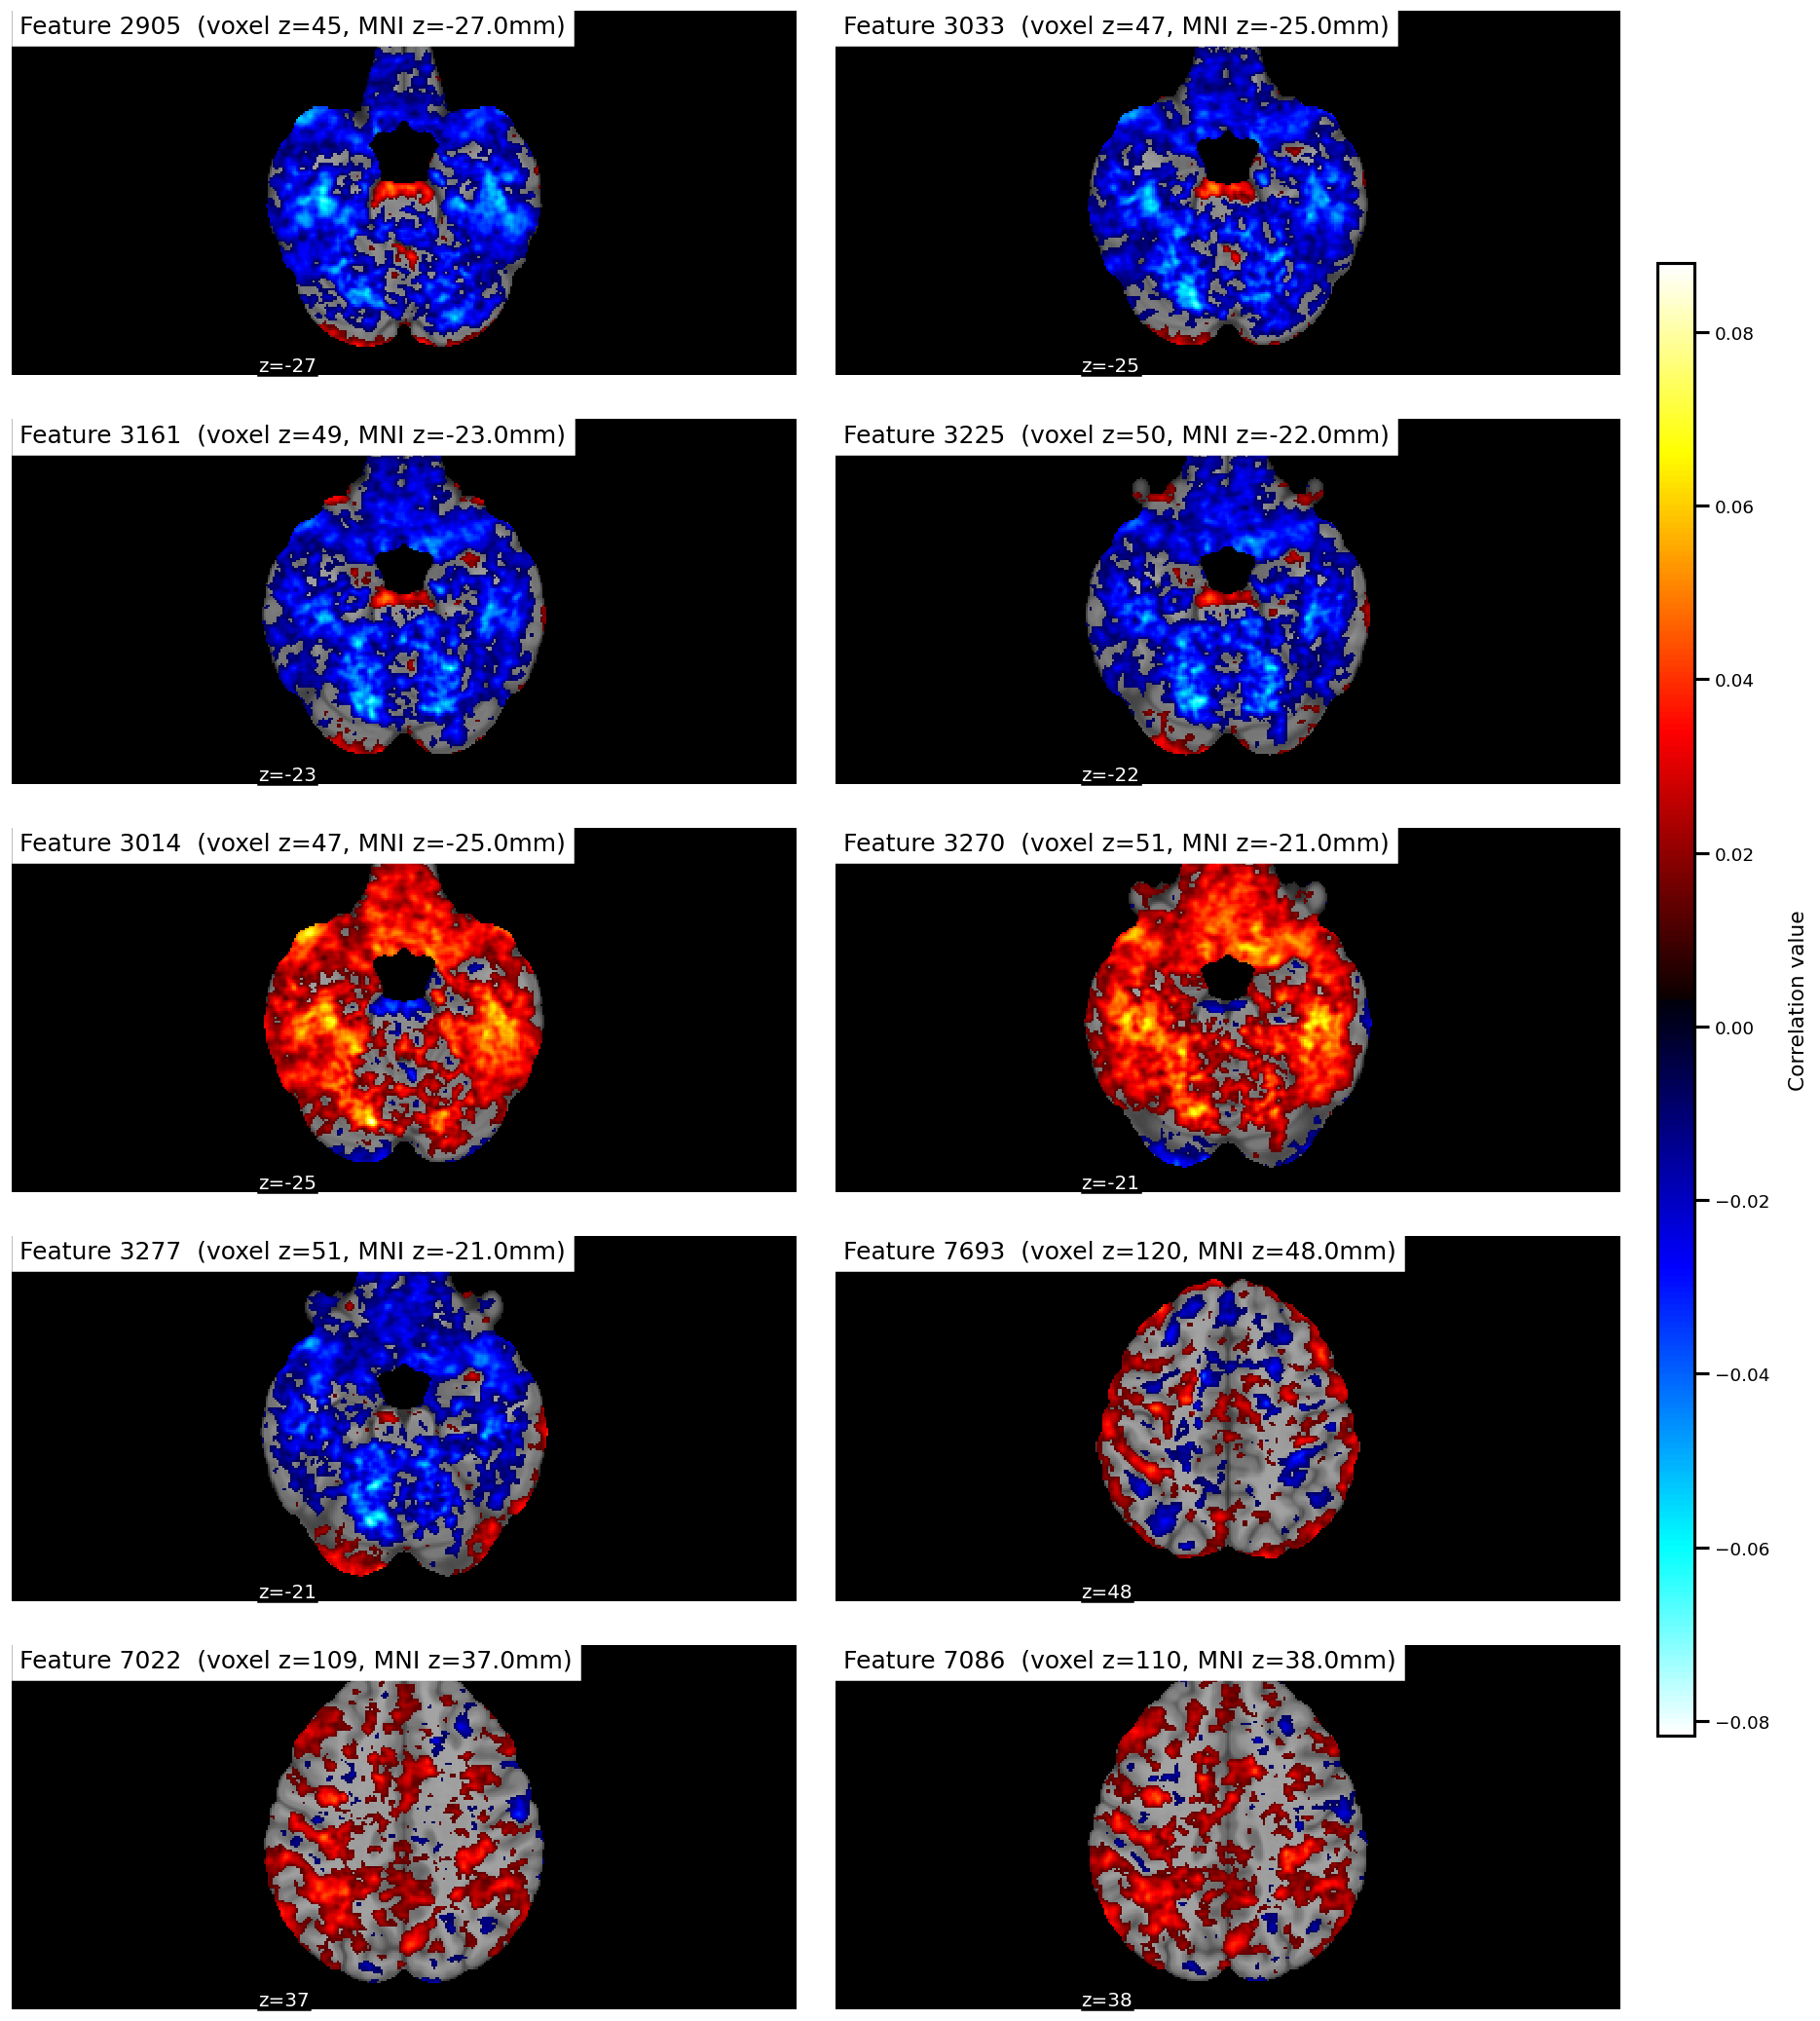

In [73]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from nilearn import plotting, datasets

BACKGROUND_IMG = datasets.load_mni152_template()

# ----------------------------
# INPUT: one voxel z-index per feature
# ----------------------------
SLICE_VOXEL_INDICES = [45, 47,49,50,47,51,51,120,109,110]  # edit these

# ----------------------------
# 1. Convert voxel indices → MNI mm using each image's affine
# ----------------------------
def voxel_z_to_mni(img, voxel_idx):
    affine = img.affine
    mni_z = affine[2, 2] * voxel_idx + affine[2, 3]
    return mni_z

# ----------------------------
# 2. Compute global vmin/vmax
# ----------------------------
all_data = [corr_maps[f0].get_fdata() for f0 in SELECTED_FEATURES[:10]]
vmin = np.nanmin([np.nanmin(d) for d in all_data])
vmax = np.nanmax([np.nanmax(d) for d in all_data])

# ----------------------------
# 3. Create subplot grid (5 rows x 2 cols)
# ----------------------------
fig = plt.figure(figsize=(16, 18))

gs = fig.add_gridspec(
    5, 2,
    left=0.02, right=0.88,
    top=0.97, bottom=0.02,
    hspace=0.12, wspace=0.05
)

axes = [fig.add_subplot(gs[r, c]) for r in range(5) for c in range(2)]

# ----------------------------
# 4. Plot — one axial slice per feature
# ----------------------------
for i in range(10):
    f0 = SELECTED_FEATURES[i]
    img0 = corr_maps[f0]

    mni_z = voxel_z_to_mni(img0, SLICE_VOXEL_INDICES[i])

    plotting.plot_stat_map(
        img0,
        bg_img=BACKGROUND_IMG,
        threshold=0.01,
        display_mode="z",
        cut_coords=[mni_z],
        colorbar=False,
        title=f"Feature {f0}  (voxel z={SLICE_VOXEL_INDICES[i]}, MNI z={mni_z:.1f}mm)",
        axes=axes[i],
        figure=fig,
        vmax=vmax
    )

# ----------------------------
# 5. Single shared colorbar on the right
# ----------------------------
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.70])

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap='cold_hot')
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Correlation value", fontsize=13, labelpad=12)
cbar.ax.tick_params(labelsize=11)

# ----------------------------
# 6. Save + show
# ----------------------------
plt.savefig(path + f'/features_brain_plot_{date}.png', dpi=150, bbox_inches='tight')
plt.savefig(path + f'/features_brain_plot_{date}.svg', format='svg', bbox_inches='tight')
plt.show()

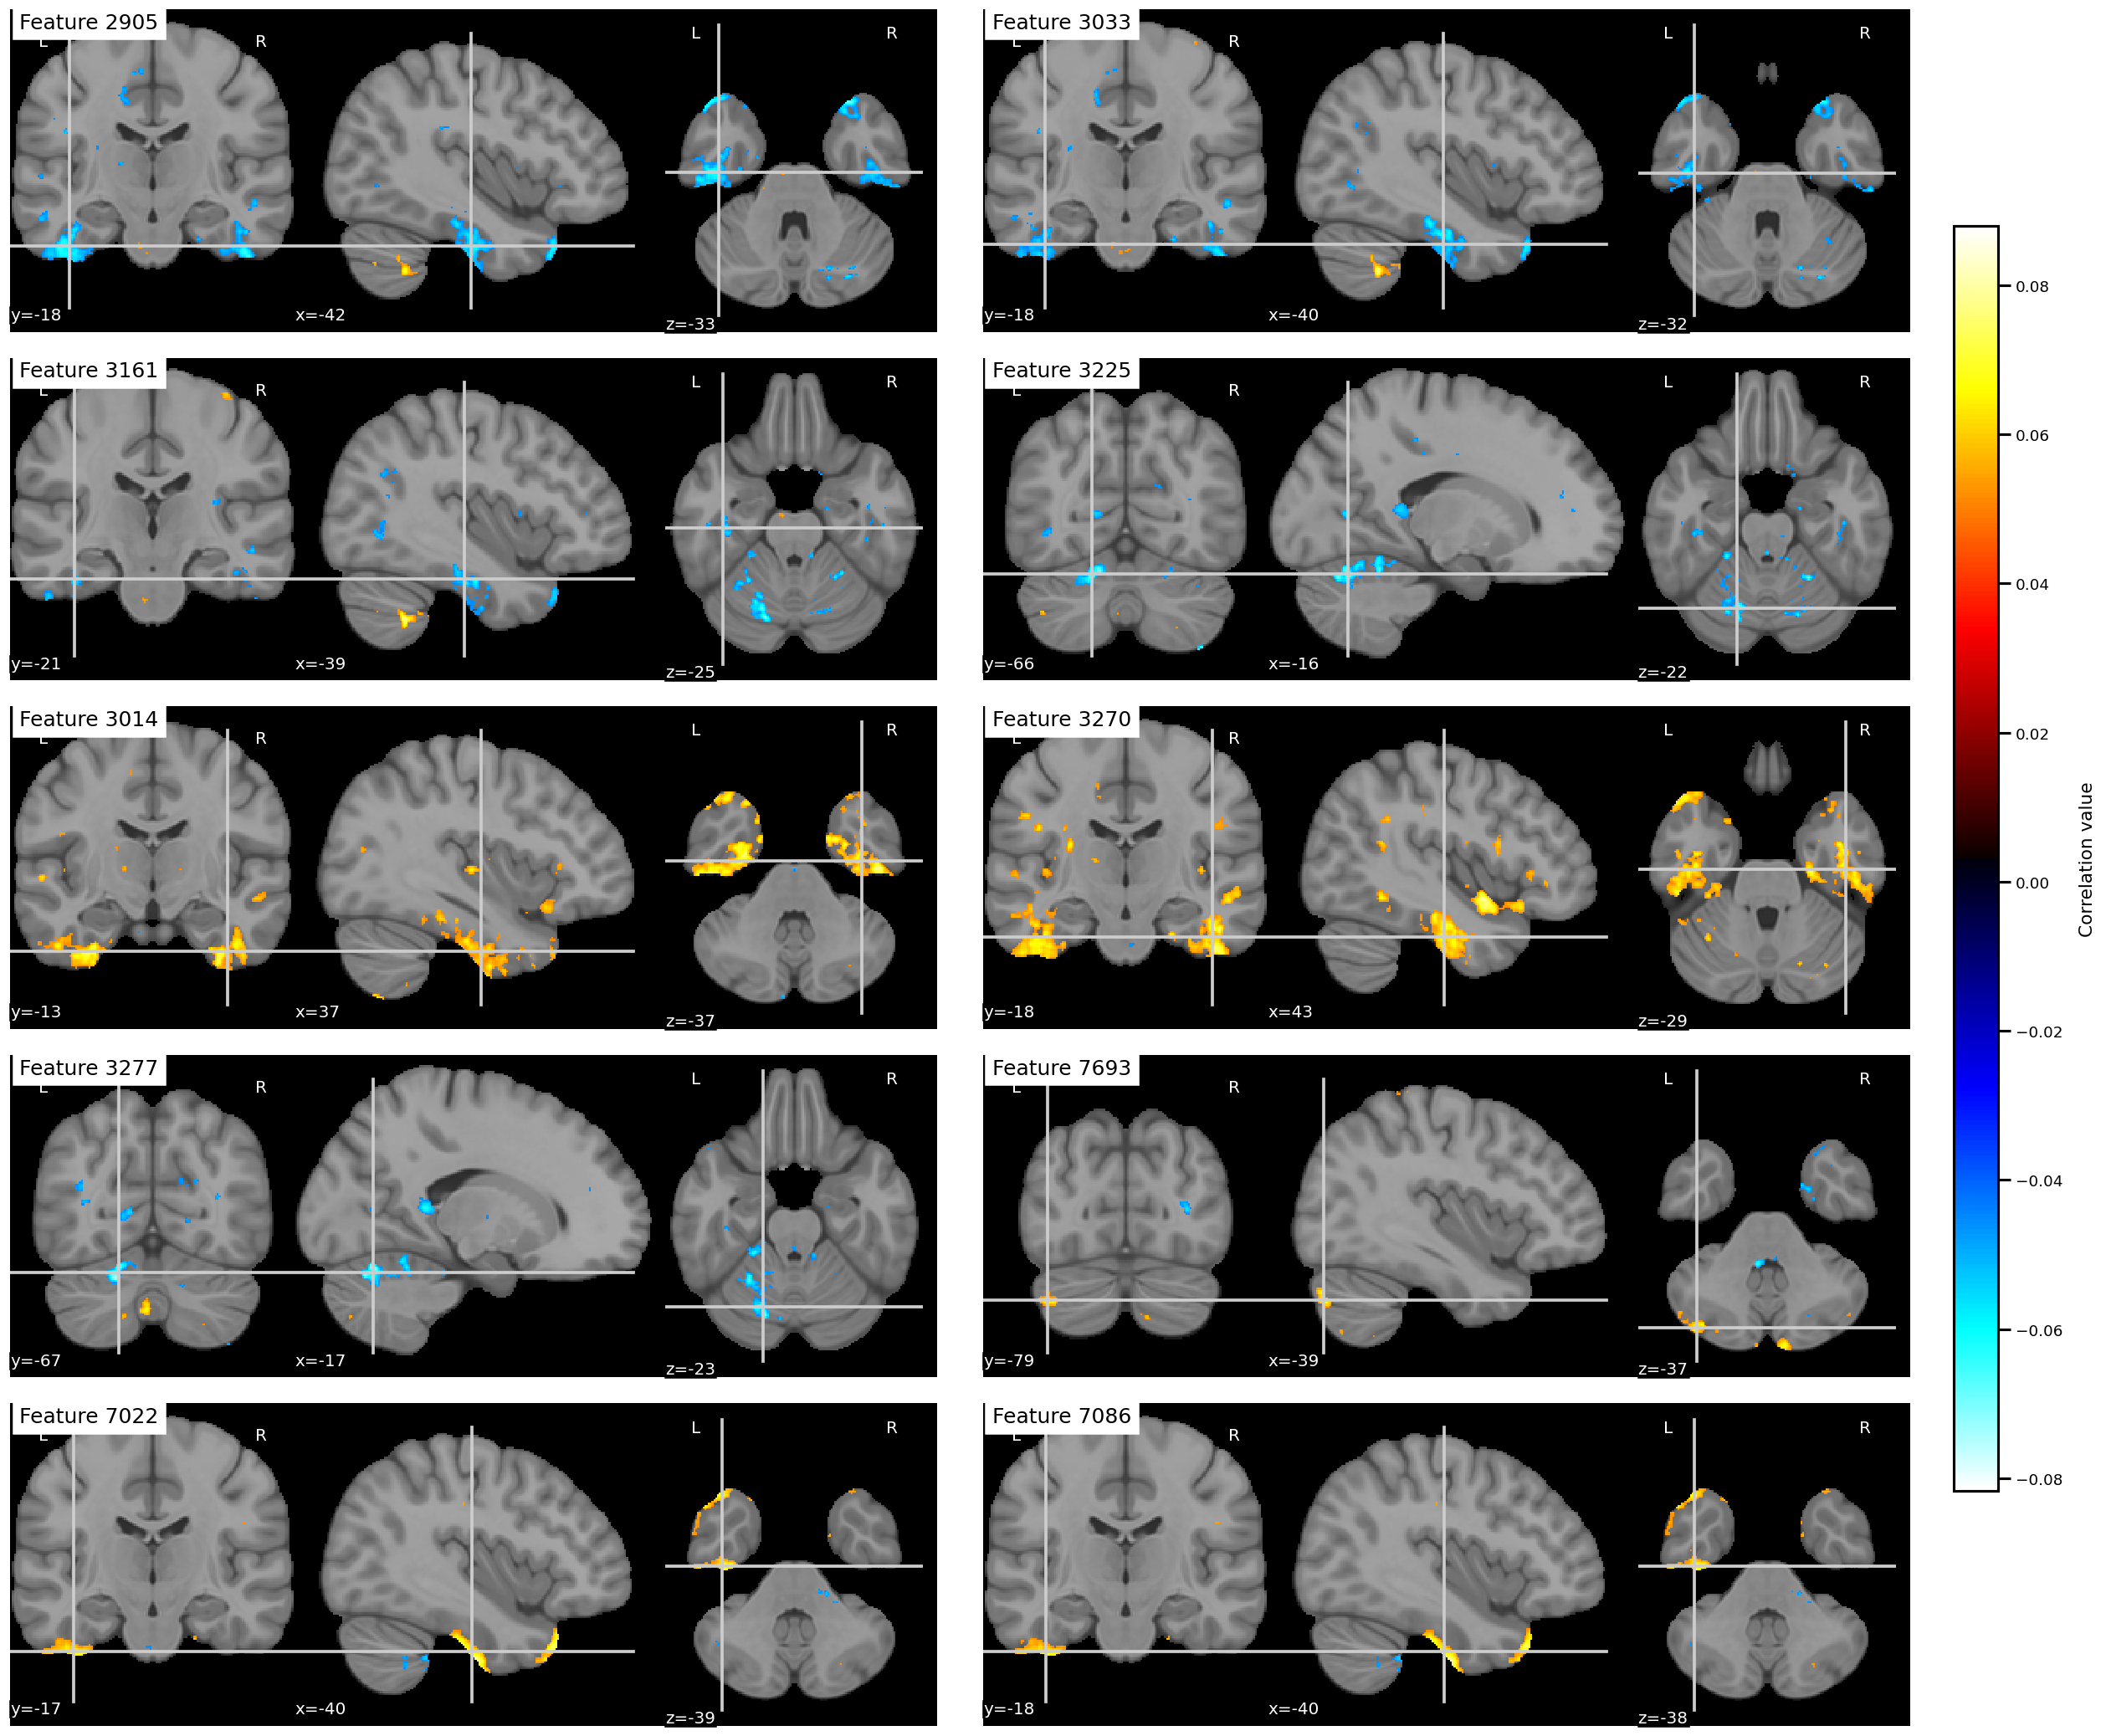

In [79]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from nilearn import plotting, datasets

BACKGROUND_IMG = datasets.load_mni152_template()

# ----------------------------
# 1. Compute global vmin/vmax
# ----------------------------
all_data = [corr_maps[f0].get_fdata() for f0 in SELECTED_FEATURES[:10]]
vmin = np.nanmin([np.nanmin(d) for d in all_data])
vmax = np.nanmax([np.nanmax(d) for d in all_data])

# ----------------------------
# 2. Create subplot grid (5 rows x 2 cols)
#    Reserve right margin for shared colorbar
# ----------------------------
fig = plt.figure(figsize=(22, 18))

# Leave ~5% on the right for the colorbar
gs = fig.add_gridspec(
    5, 2,
    left=0.02, right=0.88,
    top=0.97, bottom=0.02,
    hspace=0.08, wspace=0.05
)

axes = [fig.add_subplot(gs[r, c]) for r in range(5) for c in range(2)]

# ----------------------------
# 3. Plot maps — no individual colorbars
# ----------------------------
for i in range(10):
    
    f0 = SELECTED_FEATURES[i]
    img0 = corr_maps[f0]
    peak_coords = plotting.find_xyz_cut_coords(img0, activation_threshold=0.05)

    
    plotting.plot_stat_map(
        img0,
        bg_img=BACKGROUND_IMG,
        #threshold=0.05,
        display_mode="ortho",
        cut_coords=peak_coords,
        colorbar=False,          # ← disabled per-plot colorbar
        title=f"Feature {f0}",
        axes=axes[i],
        figure=fig,
        vmax=vmax
    )

# ----------------------------
# 4. Single shared colorbar on the right
# ----------------------------
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.70])  # [left, bottom, width, height]

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap='cold_hot')
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Correlation value", fontsize=13, labelpad=12)
cbar.ax.tick_params(labelsize=11)

# ----------------------------
# 5. Save + show
# ----------------------------
plt.savefig(path + f'/features_brain_plot_{date}.png', dpi=150, bbox_inches='tight')
plt.savefig(path + f'/features_brain_plot_{date}.svg', format='svg', bbox_inches='tight')
plt.show()

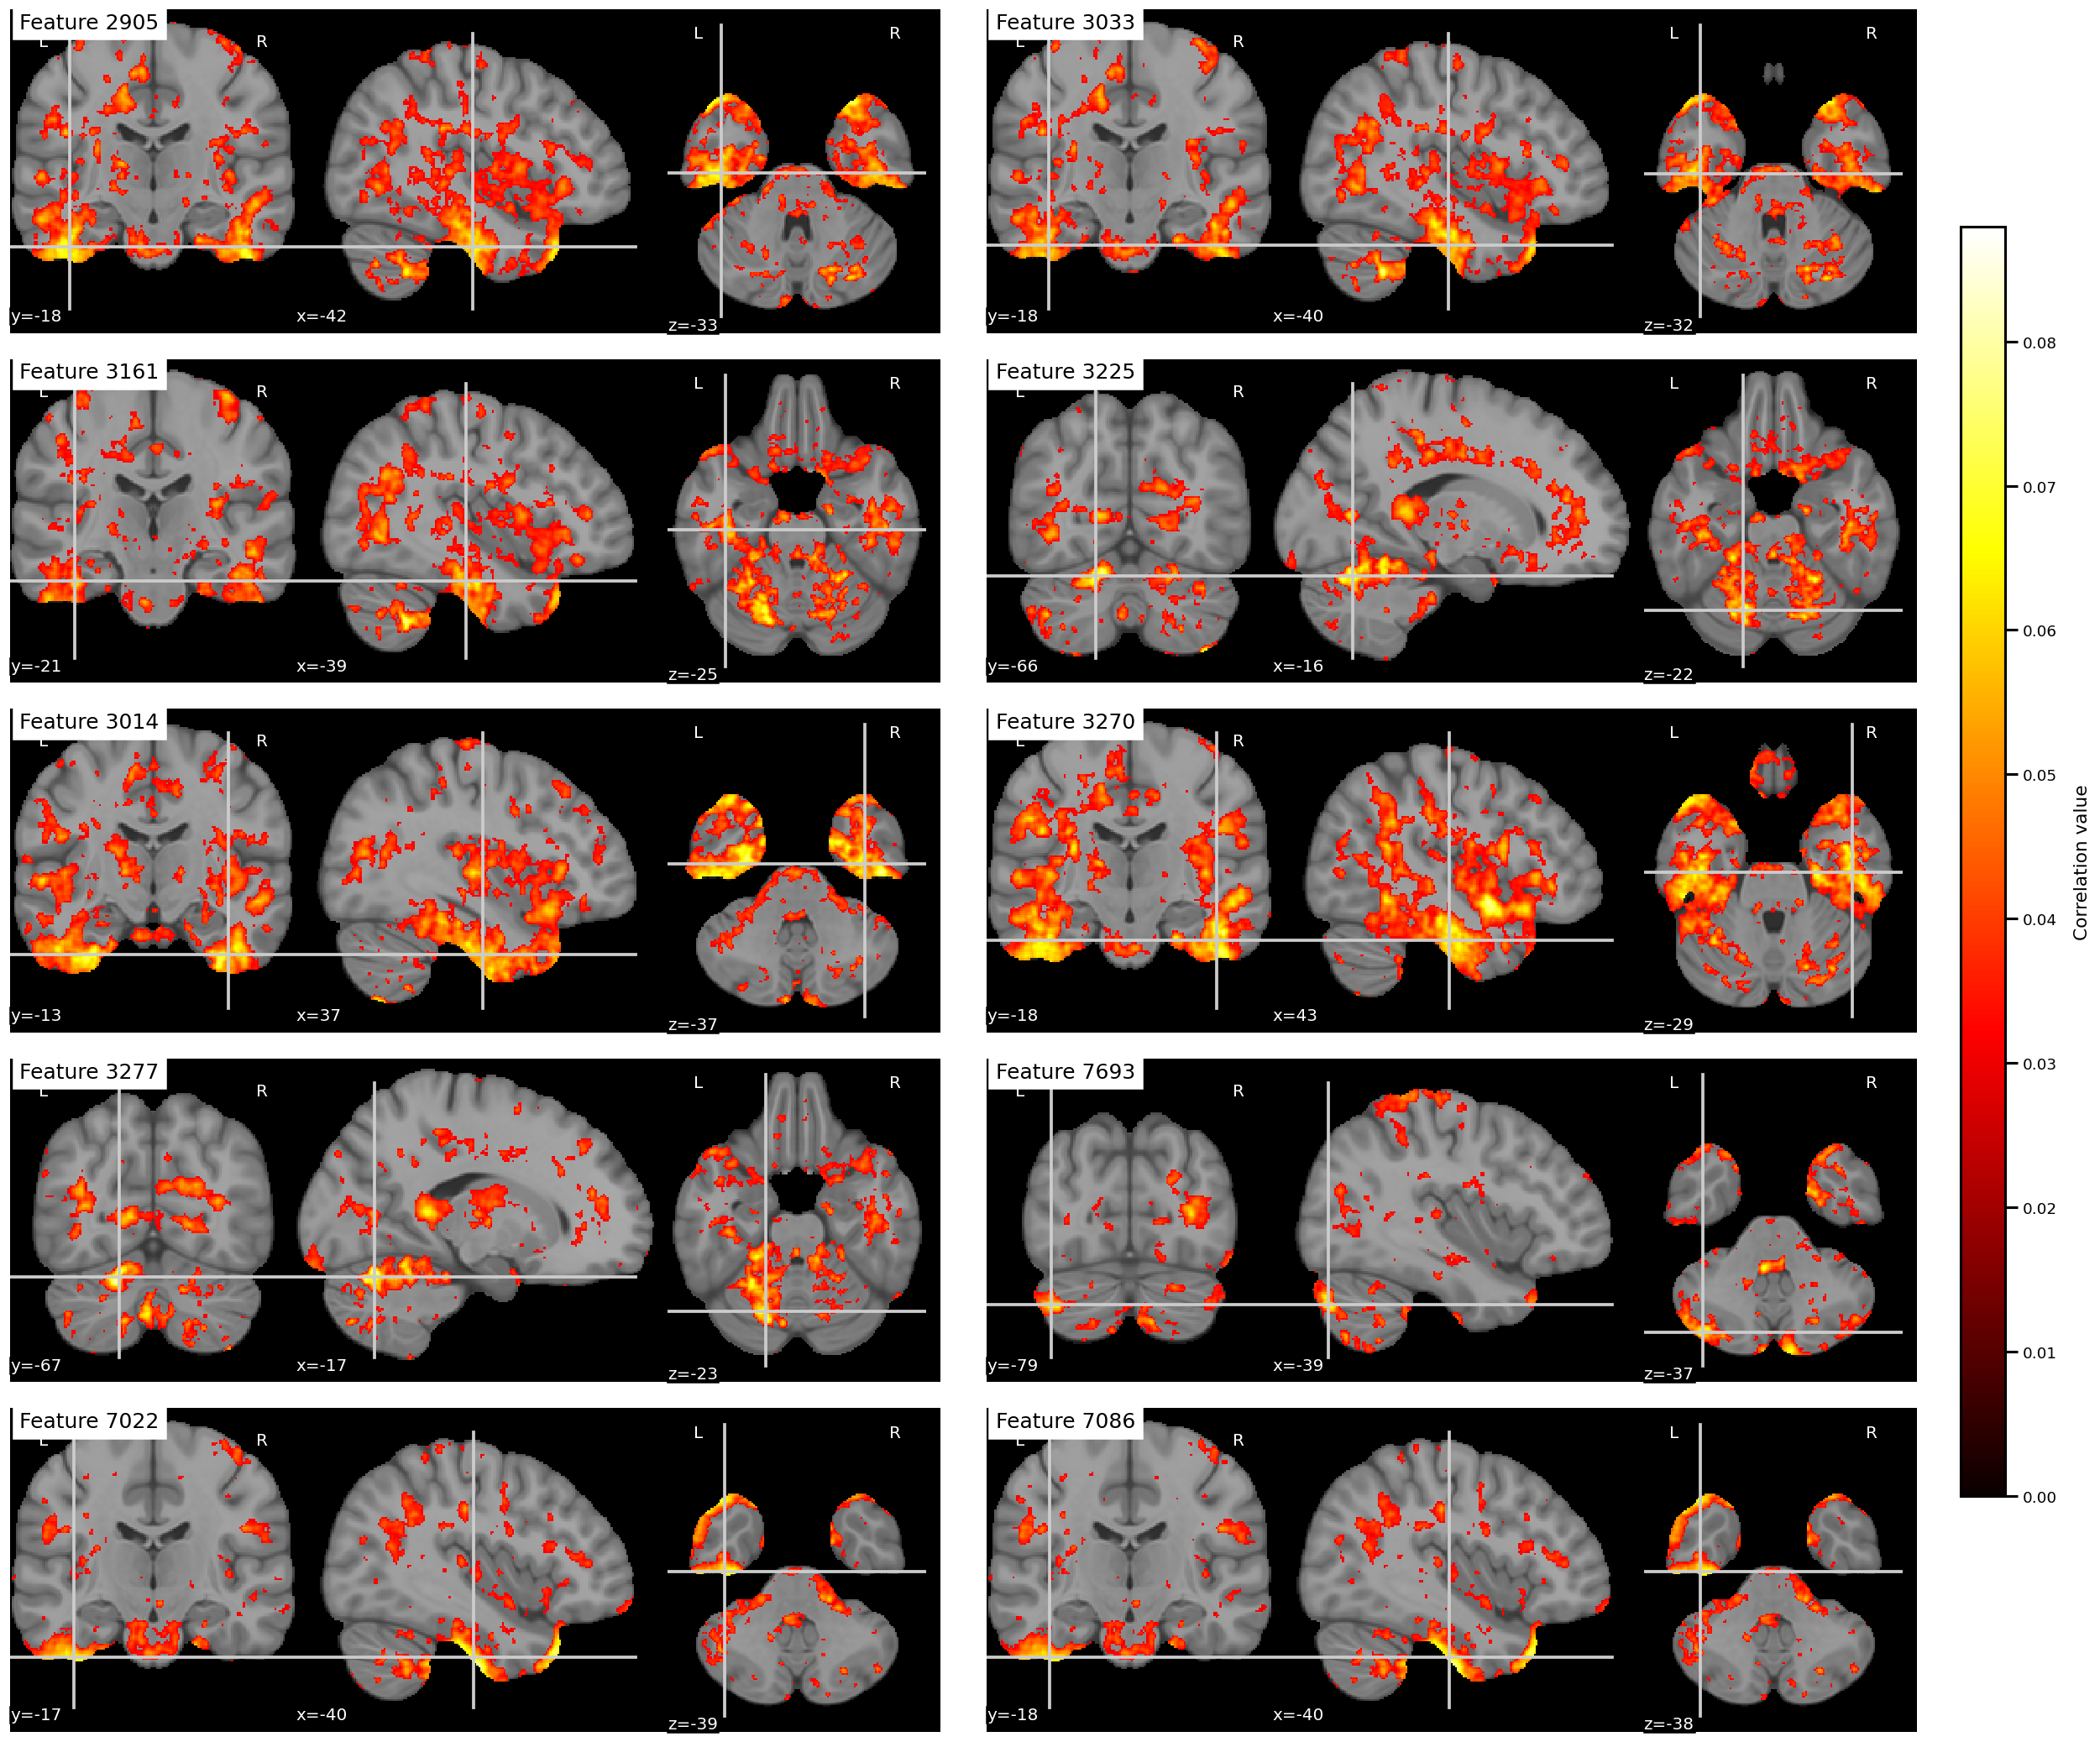

In [84]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from nilearn import plotting, datasets

BACKGROUND_IMG = datasets.load_mni152_template()

# ----------------------------
# 1. Compute global vmin/vmax
# ----------------------------
all_data = [corr_maps[f0].get_fdata() for f0 in SELECTED_FEATURES[:10]]
all_data = np.abs(all_data)

#vmin = np.nanmin([np.nanmin(d) for d in all_data])
vmax = np.nanmax([np.nanmax(d) for d in all_data])

# ----------------------------
# 2. Create subplot grid (5 rows x 2 cols)
#    Reserve right margin for shared colorbar
# ----------------------------
fig = plt.figure(figsize=(22, 18))

# Leave ~5% on the right for the colorbar
gs = fig.add_gridspec(
    5, 2,
    left=0.02, right=0.88,
    top=0.97, bottom=0.02,
    hspace=0.08, wspace=0.05
)

axes = [fig.add_subplot(gs[r, c]) for r in range(5) for c in range(2)]

# ----------------------------
# 3. Plot maps — no individual colorbars
# ----------------------------
for i in range(10):
    
    f0 = SELECTED_FEATURES[i]
    img0 = corr_maps[f0]
    img0 = nib.Nifti1Image(np.abs(img0.get_fdata()), img0.affine, img0.header)
    peak_coords = plotting.find_xyz_cut_coords(img0, activation_threshold=0.05)

    
    plotting.plot_stat_map(
        img0,
        bg_img=BACKGROUND_IMG,
        threshold=0.03,
        display_mode="ortho",
        cut_coords=peak_coords,
        colorbar=False,          # ← disabled per-plot colorbar
        title=f"Feature {f0}",
        axes=axes[i],
        figure=fig,
        vmax=vmax
    )

# ----------------------------
# 4. Single shared colorbar on the right
# ----------------------------
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.70])  # [left, bottom, width, height]

norm = mpl.colors.Normalize(vmin=0, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap='hot')
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Correlation value", fontsize=13, labelpad=12)
cbar.ax.tick_params(labelsize=11)

# ----------------------------
# 5. Save + show
# ----------------------------
plt.savefig(path + f'/features_brain_plot_{date}.png', dpi=150, bbox_inches='tight')
plt.savefig(path + f'/features_brain_plot_{date}.svg', format='svg', bbox_inches='tight')
plt.show()

In [86]:
mask_img = datasets.load_mni152_brain_mask()
ref_img = nib.load(pet_paths[0])
# Sanity check: same shape/affine
ref_shape = ref_img.shape
ref_aff = ref_img.affine

if mask_img.shape != ref_img.shape:
    mask_img = image.resample_to_img(mask_img, ref_img, interpolation="nearest")


In [85]:
corr_vectors={}
for number,feature in enumerate(SELECTED_FEATURES):
    corr_vectors[feature] = masking.apply_mask(corr_maps[feature], mask_img).astype(np.float32)

In [87]:
# Fetch atlas (first run downloads to nilearn cache)
atlas = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
atlas_img = atlas.maps
atlas_labels = atlas.labels

In [88]:


#Instead of thousands of voxels, tell me which anatomical regions matter most.

# Resample atlas to PET space
atlas_res = image.resample_to_img(atlas_img, ref_img, interpolation="nearest")
atlas_data = atlas_res.get_fdata().astype(int)

# Mask atlas to the same brain mask voxels
atlas_in_mask = masking.apply_mask(atlas_res, mask_img).astype(int)  # (n_voxels,)

# Region ids present (exclude 0 which is 'Background')
region_ids = np.unique(atlas_in_mask)
region_ids = region_ids[region_ids != 0]
print("Regions in mask:", len(region_ids))

# Precompute voxel indices per region for speed
region_to_vox = {rid: np.where(atlas_in_mask == rid)[0] for rid in region_ids}


def summarize_regions(r: np.ndarray, top_k: int = 15, use_abs: bool = True) -> pd.DataFrame:
    rows = []
    for rid, vox_idx in region_to_vox.items():
        if vox_idx.size == 0:
            continue
        vals = r[vox_idx]
        score = float(np.mean(np.abs(vals))) if use_abs else float(np.mean(vals))
        label = atlas_labels[rid] if rid < len(atlas_labels) else f"Region {rid}"
        rows.append({"region_id": int(rid), "region": label, "score": score, "n_vox": int(vox_idx.size)})
    df = pd.DataFrame(rows).sort_values("score", ascending=False).head(top_k).reset_index(drop=True)
    return df

# Example summary for first feature
region_df0 = summarize_regions(corr_vectors['2905'], top_k=20, use_abs=True)
region_df0
#score - average correlation for the region

Regions in mask: 48


,region_id,region,score,n_vox
0,37,"Temporal Fusiform Cortex, anterior division",0.039605,4739
1,38,"Temporal Fusiform Cortex, posterior division",0.038309,12676
2,15,"Inferior Temporal Gyrus, posterior division",0.032869,15426
3,41,Frontal Operculum Cortex,0.030834,5496
4,28,Paracingulate Gyrus,0.030554,23552
5,2,Insular Cortex,0.028956,18728
6,27,Subcallosal Cortex,0.028635,9134
7,33,Frontal Orbital Cortex,0.028576,25149
8,44,Planum Polare,0.027990,5992
9,24,Intracalcarine Cortex,0.027090,11208


In [89]:
def build_region_feature_table(corr_vectors, use_abs=True):
    rows = []

    for f, r in corr_vectors.items():  # loop over features
        for rid, vox_idx in region_to_vox.items():
            if vox_idx.size == 0:
                continue

            vals = r[vox_idx]
            score = float(np.mean(np.abs(vals))) if use_abs else float(np.mean(vals))
            label = atlas_labels[rid] if rid < len(atlas_labels) else f"Region {rid}"

            rows.append({
                "feature": f,
                "region_id": int(rid),
                "region": label,
                "score": score
            })

    df = pd.DataFrame(rows)
    return df

In [90]:
region_feature_df = build_region_feature_table(corr_vectors)

heatmap_df = region_feature_df.pivot(
    index="region",
    columns="feature",
    values="score"
)

In [91]:
heatmap_df

feature,2905,3014,3033,3161,3225,3270,3277,7022,7086,7693
region,,,,,,,,,,
Angular Gyrus,0.017581,0.022829,0.018993,0.018468,0.017475,0.023237,0.016349,0.014878,0.015676,0.010532
Central Opercular Cortex,0.018747,0.018474,0.018241,0.018472,0.018054,0.023612,0.013836,0.010974,0.010917,0.015351
"Cingulate Gyrus, anterior division",0.020715,0.026476,0.019294,0.017806,0.016585,0.027081,0.016254,0.013455,0.012752,0.009520
"Cingulate Gyrus, posterior division",0.021206,0.025826,0.020692,0.019019,0.017911,0.026868,0.018345,0.012177,0.011795,0.010338
Cuneal Cortex,0.022066,0.025365,0.020199,0.017663,0.015843,0.024523,0.017479,0.010687,0.011221,0.008361
Frontal Medial Cortex,0.024224,0.031348,0.024065,0.022795,0.021402,0.033698,0.022901,0.012480,0.012491,0.011313
Frontal Operculum Cortex,0.030834,0.031346,0.028980,0.028096,0.026758,0.034986,0.019929,0.012868,0.011472,0.014462
Frontal Orbital Cortex,0.028576,0.030701,0.027951,0.026971,0.025676,0.032046,0.018931,0.019356,0.018399,0.009326
Frontal Pole,0.012782,0.020180,0.012667,0.012252,0.011950,0.018375,0.011396,0.009230,0.009294,0.009141


In [92]:
top_regions = (
    region_feature_df
    .groupby("region")["score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

heatmap_df = heatmap_df.loc[top_regions]

In [93]:
heatmap_df

feature,2905,3014,3033,3161,3225,3270,3277,7022,7086,7693
region,,,,,,,,,,
"Temporal Fusiform Cortex, anterior division",0.039605,0.048137,0.034852,0.031356,0.029352,0.046001,0.029514,0.019476,0.020198,0.016571
"Temporal Fusiform Cortex, posterior division",0.038309,0.042530,0.034192,0.030577,0.028314,0.043389,0.024389,0.021270,0.021794,0.012379
Subcallosal Cortex,0.028635,0.034024,0.027913,0.027374,0.025953,0.036864,0.020862,0.022622,0.022593,0.010906
Planum Polare,0.027990,0.033074,0.026013,0.024882,0.023991,0.035812,0.032519,0.016572,0.015839,0.016767
"Inferior Temporal Gyrus, posterior division",0.032869,0.036354,0.028968,0.025634,0.023092,0.035727,0.018790,0.018510,0.019839,0.013300
Insular Cortex,0.028956,0.030012,0.028052,0.027636,0.026380,0.034803,0.024264,0.015692,0.014764,0.015668
Paracingulate Gyrus,0.030554,0.036967,0.029165,0.026956,0.025063,0.036750,0.024856,0.013576,0.012382,0.009873
Frontal Operculum Cortex,0.030834,0.031346,0.028980,0.028096,0.026758,0.034986,0.019929,0.012868,0.011472,0.014462
Frontal Orbital Cortex,0.028576,0.030701,0.027951,0.026971,0.025676,0.032046,0.018931,0.019356,0.018399,0.009326


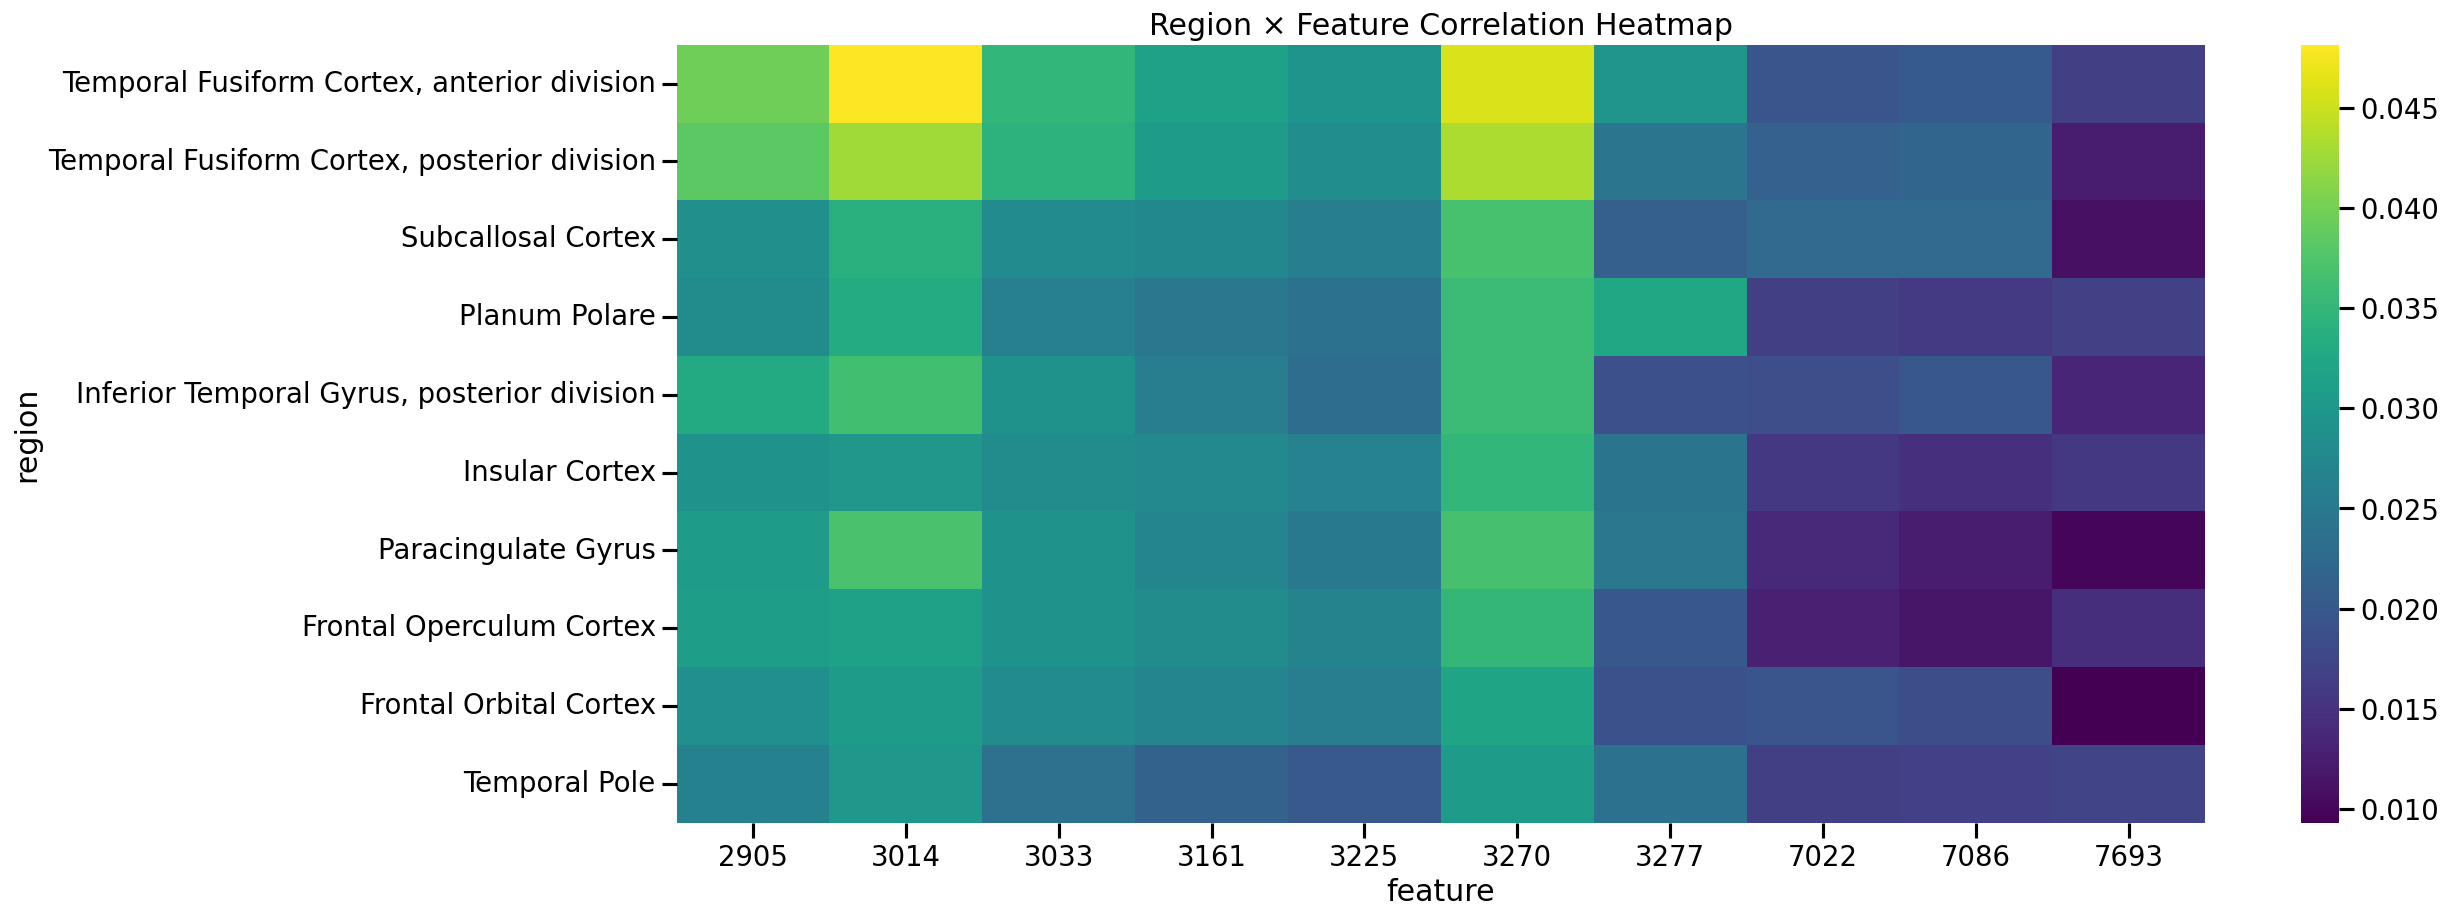

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 8))
sns.heatmap(heatmap_df, cmap="viridis")
plt.title("Region × Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

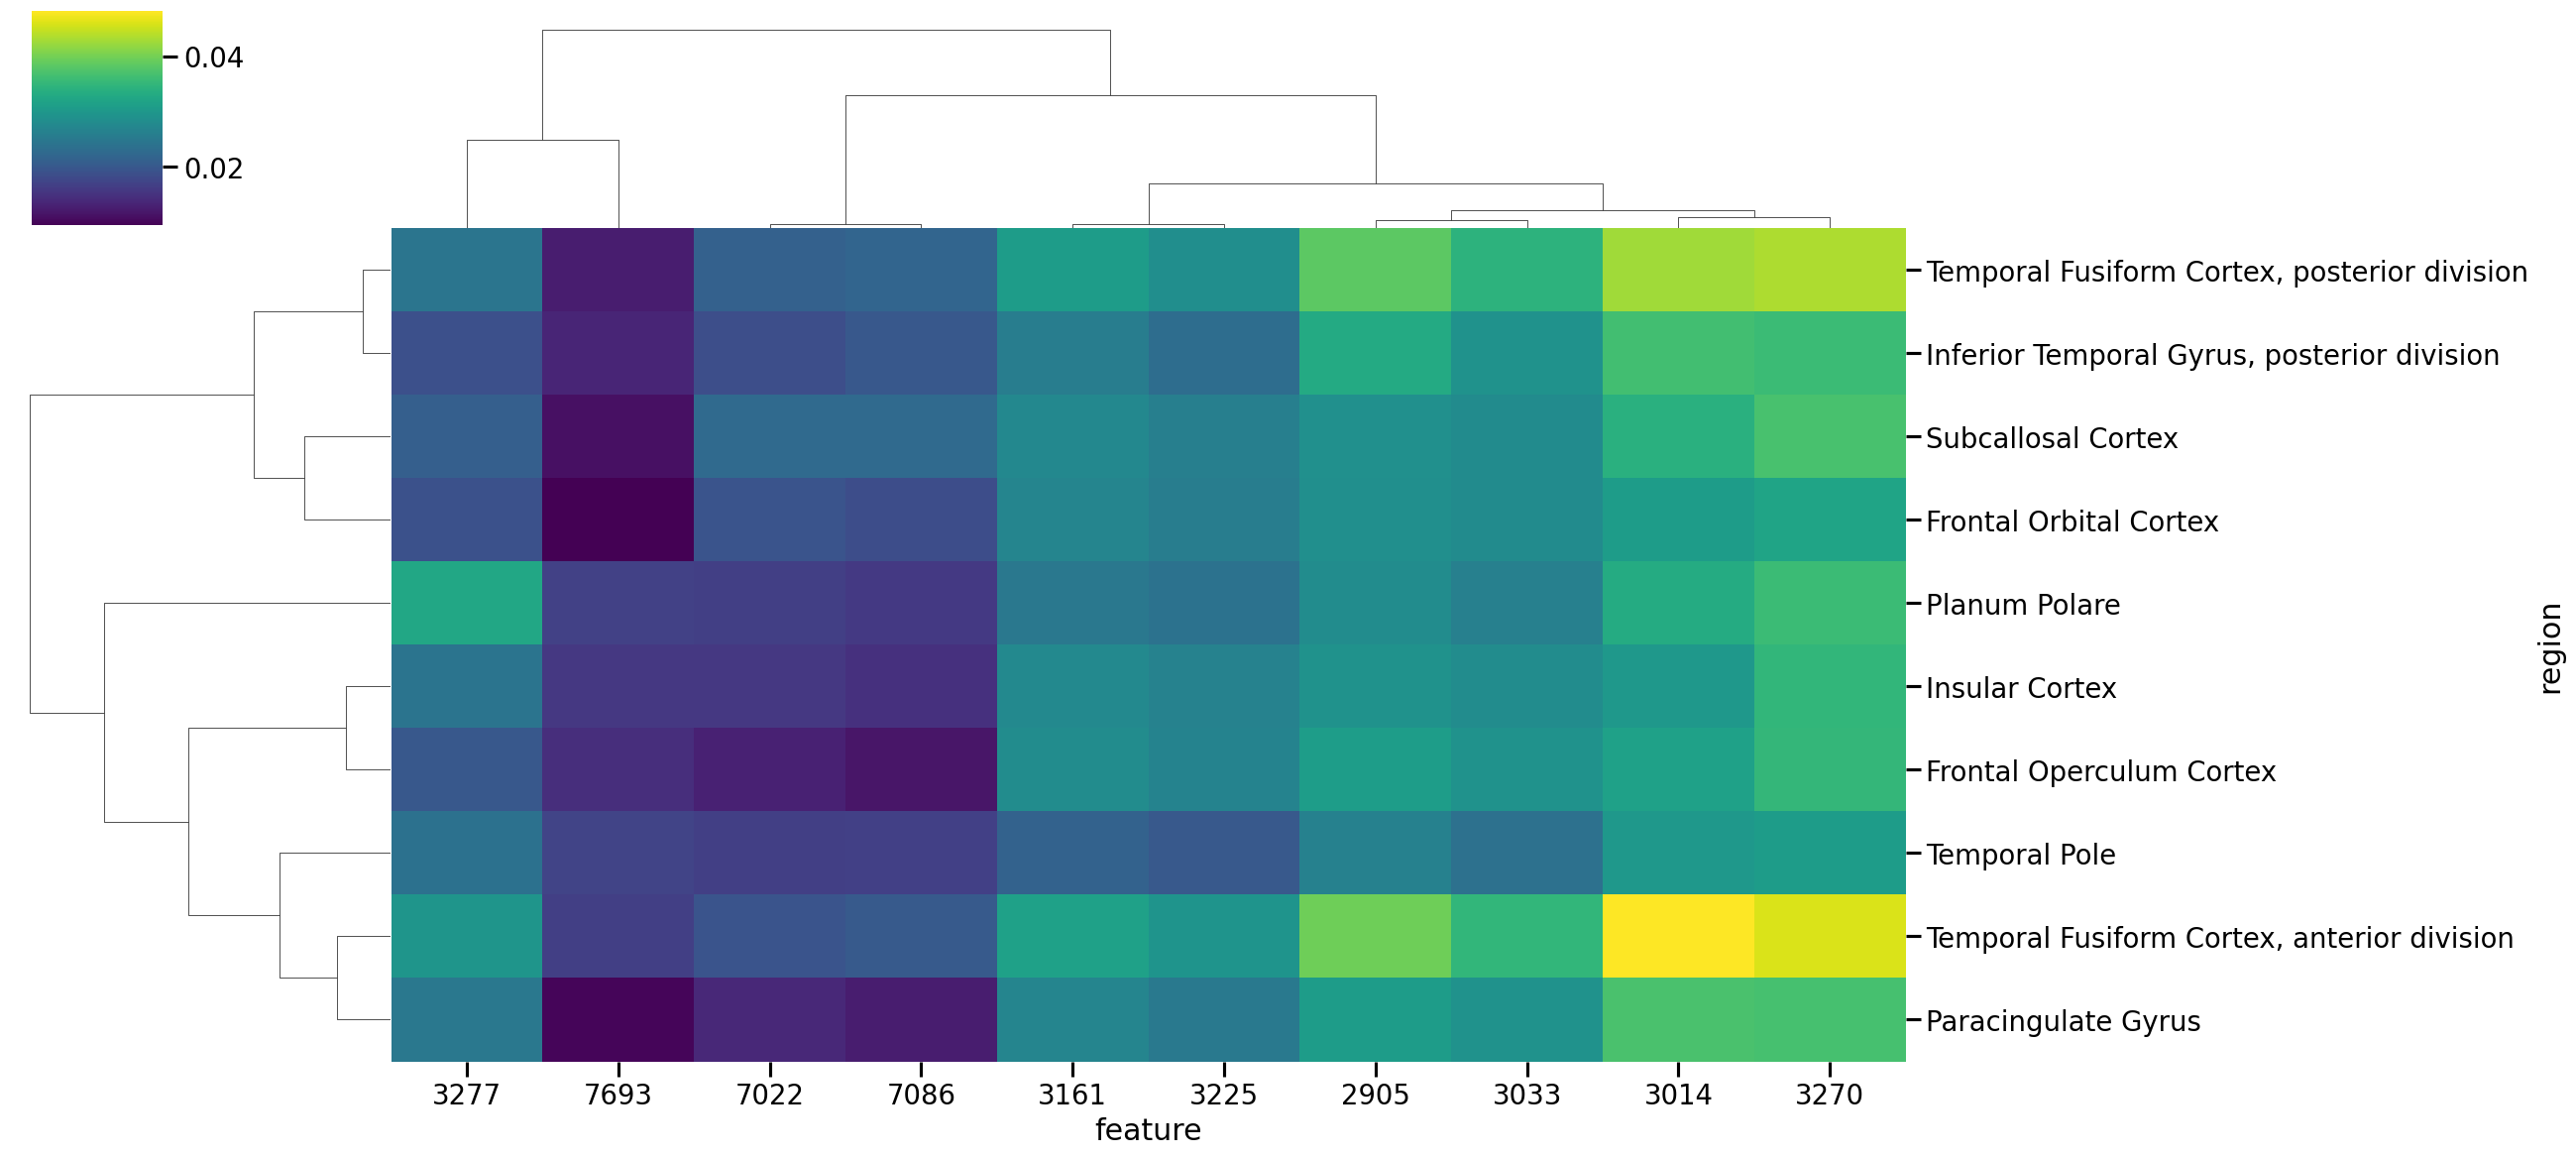

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(
    heatmap_df,          # or heatmap_df
    cmap="viridis",
    figsize=(22, 10),
    metric="correlation",  # IMPORTANT for your use case
    method="average"
)

plt.show()